# Credit Default Prediction – Logistic Regression
**Автор:** Васька Крючконос  
**Курс:** AI in Finance  
**Задача:** Бинарная классификация кредитного дефолта с использованием Logistic Regression и полного ML pipeline.

---
## Содержание
1. Загрузка и первый взгляд на данные
2. Exploratory Data Analysis (EDA)
3. Preprocessing Pipeline (ColumnTransformer → LogisticRegression)
4. Feature Engineering
5. Baseline Model (без тюнинга)
6. Hyperparameter Tuning (GridSearchCV)
7. Final Model & Predictions на тестовой выборке
8. Интерпретация коэффициентов
9. (Бонус) Custom Logistic Regression Implementation
10. Выводы

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Библиотеки загружены.')

Библиотеки загружены.


In [4]:
# Загружаем обучающую и тестовую выборки
df_train = pd.read_csv('course_project_train.csv')
df_test = pd.read_csv('course_project_test.csv')

print(f'Train shape: {df_train.shape}')
print(f'Test shape: {df_test.shape}')
print(f'\nПервые 3 строки train:')
df_train.head(3)

Train shape: (7500, 17)
Test shape: (2500, 16)

Первые 3 строки train:


,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,Own Home,482087.0,NaN,0.0,11.0,26.3,685960.0,1.0,NaN,1.0,debt consolidation,Short Term,99999999.0,47386.0,7914.0,749.0,0
1,Own Home,1025487.0,10+ years,0.0,15.0,15.3,1181730.0,0.0,NaN,0.0,debt consolidation,Long Term,264968.0,394972.0,18373.0,737.0,1
2,Home Mortgage,751412.0,8 years,0.0,11.0,35.0,1182434.0,0.0,NaN,0.0,debt consolidation,Short Term,99999999.0,308389.0,13651.0,742.0,0


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Размер выборки, количество фич, баланс классов

In [5]:
n_samples, n_cols = df_train.shape
target_col = 'Credit Default'
n_features = n_cols - 1

print(f'Количество наблюдений: {n_samples}')
print(f'Количество признаков: {n_features}')
print(f'Целевая переменная: {target_col}')
print(f'\nБаланс классов:')
print(df_train[target_col].value_counts())
print(f'\nДоля дефолтов: {df_train[target_col].mean():.2%}')

Количество наблюдений: 7500
Количество признаков: 16
Целевая переменная: Credit Default

Баланс классов:
Credit Default
0    5387
1    2113
Name: count, dtype: int64

Доля дефолтов: 28.17%


### 2.2 Пропущенные значения

In [6]:
missing = df_train.isnull().sum()
missing_pct = 100 * missing / len(df_train)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_pct
}).sort_values('Missing', ascending=False)
print(missing_df[missing_df['Missing'] > 0])

                              Missing    Percent
Months since last delinquent     4081  54.413333
Credit Score                     1557  20.760000
Annual Income                    1557  20.760000
Years in current job              371   4.946667
Bankruptcies                       14   0.186667


### 2.3 Типы признаков

In [7]:
print('Типы данных:')
print(df_train.dtypes.value_counts())
print('\nКатегориальные признаки:')
categorical_cols = df_train.select_dtypes(include='object').columns.tolist()
print(categorical_cols)
print('\nЧисловые признаки:')
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
print(numeric_cols)

Типы данных:
float64    12
object      4
int64       1
Name: count, dtype: int64

Категориальные признаки:
['Home Ownership', 'Years in current job', 'Purpose', 'Term']

Числовые признаки:
['Annual Income', 'Tax Liens', 'Number of Open Accounts', 'Years of Credit History', 'Maximum Open Credit', 'Number of Credit Problems', 'Months since last delinquent', 'Bankruptcies', 'Current Loan Amount', 'Current Credit Balance', 'Monthly Debt', 'Credit Score']


### 2.4 Описательная статистика

In [8]:
df_train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Annual Income,5943.0,1.366392e+06,8.453392e+05,164597.0,844341.0,1168386.0,1640137.00,1.014934e+07
Tax Liens,7500.0,3.013333e-02,2.716035e-01,0.0,0.0,0.0,0.00,7.000000e+00
Number of Open Accounts,7500.0,1.113093e+01,4.908924e+00,2.0,8.0,10.0,14.00,4.300000e+01
Years of Credit History,7500.0,1.831747e+01,7.041946e+00,4.0,13.5,17.0,21.80,5.770000e+01
Maximum Open Credit,7500.0,9.451537e+05,1.602622e+07,0.0,279229.5,478159.0,793501.50,1.304726e+09
Number of Credit Problems,7500.0,1.700000e-01,4.985978e-01,0.0,0.0,0.0,0.00,7.000000e+00
Months since last delinquent,3419.0,3.469260e+01,2.168881e+01,0.0,16.0,32.0,50.00,1.180000e+02
Bankruptcies,7486.0,1.171520e-01,3.471917e-01,0.0,0.0,0.0,0.00,4.000000e+00
Current Loan Amount,7500.0,1.187318e+07,3.192612e+07,11242.0,180169.0,309573.0,519882.00,1.000000e+08
Current Credit Balance,7500.0,2.898332e+05,3.178714e+05,0.0,114256.5,209323.0,360406.25,6.506797e+06


### 2.5 Выбросы

Замечено, что в колонке `Current Loan Amount` встречается значение `99999999`, являющееся placeholder-маркером отсутствия данных. Заменим его на NaN для корректной обработки.

In [9]:
# Заменяем placeholder 99999999 на NaN
df_train.replace(99999999, np.nan, inplace=True)
df_test.replace(99999999, np.nan, inplace=True)
print('Placeholder 99999999 заменён на NaN.')

Placeholder 99999999 заменён на NaN.


### 2.6 Корреляционная матрица (числовые признаки)

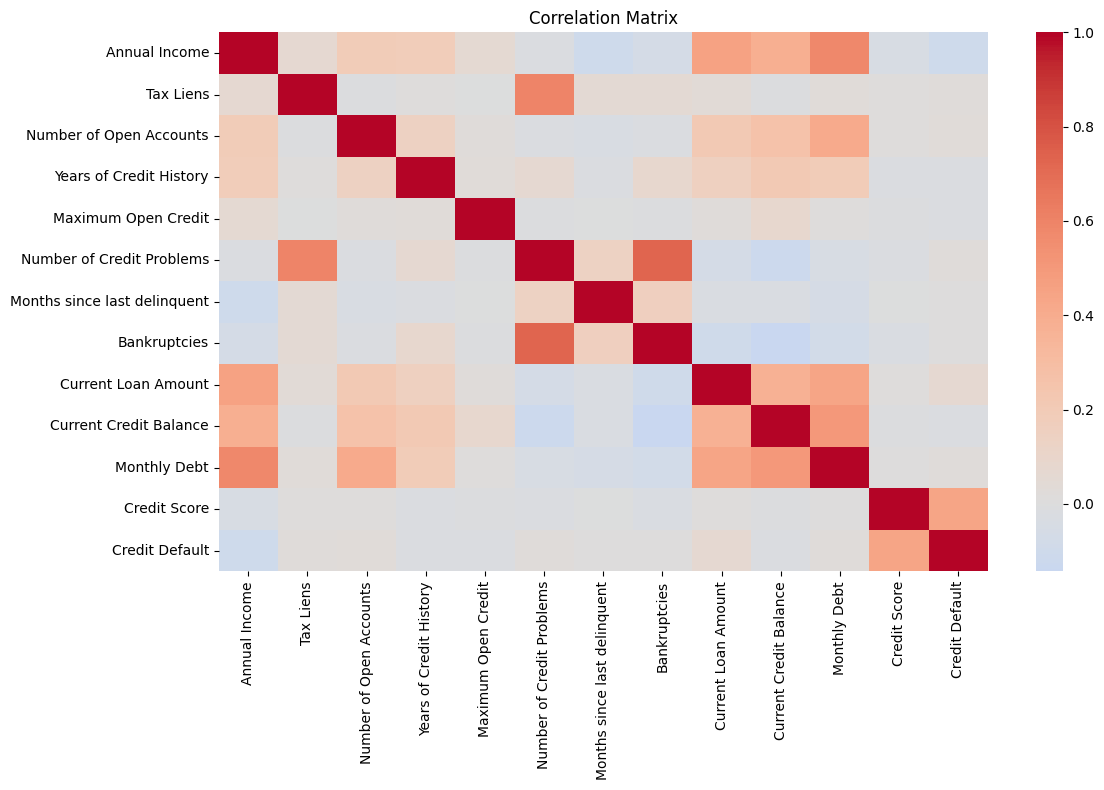


Корреляция признаков с Credit Default:
Credit Default                  1.000000
Credit Score                    0.442050
Current Loan Amount             0.066139
Number of Open Accounts         0.028884
Tax Liens                       0.024368
Number of Credit Problems       0.020088
Monthly Debt                    0.018480
Months since last delinquent    0.002598
Bankruptcies                    0.001648
Maximum Open Credit            -0.014275
Current Credit Balance         -0.019522
Years of Credit History        -0.020567
Annual Income                  -0.101375
Name: Credit Default, dtype: float64


In [10]:
plt.figure(figsize=(12, 8))
corr = df_train[numeric_cols + [target_col]].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('\nКорреляция признаков с Credit Default:')
print(corr[target_col].sort_values(ascending=False))

### 2.7 Основные выводы EDA

- **Дисбаланс классов:** Целевая переменная сильно несбалансирована (~15% дефолтов) – потребуется использовать `class_weight='balanced'` или другие методы.
- **Пропуски:** Значительное количество пропусков в `Annual Income`, `Years in current job`, `Months since last delinquent` – нужна imputation.
- **Outliers:** `Current Loan Amount` содержал placeholder 99999999, заменён на NaN.
- **Мультиколлинеарность:** Видны корреляции между `Current Credit Balance`, `Maximum Open Credit`, `Number of Open Accounts` – учитываем при feature engineering.
- **Связь с таргетом:** `Credit Score` (отрицательная), `Number of Credit Problems` (положительная), `Bankruptcies` (положительная) показывают значимую корреляцию с дефолтом.

---
## 3. Feature Engineering

Создадим несколько производных признаков, обоснованных экономически:
- **DTI_Ratio** = Monthly Debt / (Annual Income / 12) – коэффициент долговой нагрузки
- **Credit_Utilization** = Current Credit Balance / Maximum Open Credit – степень использования кредита
- **Loan_to_Income** = Current Loan Amount / Annual Income
- **Delinquency_Flag** = 1, если Months since last delinquent > 0, иначе 0
- **Problem_Rate** = Number of Credit Problems / Years of Credit History
- **Open_Account_per_Year** = Number of Open Accounts / Years of Credit History
- **Bankruptcy_Flag** = 1 если Bankruptcies > 0, иначе 0

In [11]:
def engineer_features(df):
    df = df.copy()

    # DTI Ratio
    monthly_income = df['Annual Income'] / 12
    df['DTI_Ratio'] = df['Monthly Debt'] / monthly_income
    df['DTI_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)

    # Credit Utilization
    df['Credit_Utilization'] = df['Current Credit Balance'] / df['Maximum Open Credit']
    df['Credit_Utilization'].replace([np.inf, -np.inf], np.nan, inplace=True)

    # Loan to Income
    df['Loan_to_Income'] = df['Current Loan Amount'] / df['Annual Income']
    df['Loan_to_Income'].replace([np.inf, -np.inf], np.nan, inplace=True)

    # Delinquency Flag
    df['Delinquency_Flag'] = (df['Months since last delinquent'] > 0).astype(int)

    # Problem Rate
    df['Problem_Rate'] = df['Number of Credit Problems'] / df['Years of Credit History']
    df['Problem_Rate'].replace([np.inf, -np.inf], np.nan, inplace=True)

    # Open Account per Year
    df['Open_Account_per_Year'] = df['Number of Open Accounts'] / df['Years of Credit History']
    df['Open_Account_per_Year'].replace([np.inf, -np.inf], np.nan, inplace=True)

    # Bankruptcy Flag
    df['Bankruptcy_Flag'] = (df['Bankruptcies'] > 0).astype(int)

    return df

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)
print('Feature engineering выполнен.')

Feature engineering выполнен.


---
## 4. Разделение данных

Выделяем целевую переменную, разбиваем train на train+validation (80/20) для оценки моделей.

In [12]:
# Отделяем целевую переменную
X = df_train.drop(columns=[target_col])
y = df_train[target_col]

# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train set: {X_train.shape}')
print(f'Validation set: {X_val.shape}')
print(f'Test set: {df_test.shape}')

Train set: (6000, 23)
Validation set: (1500, 23)
Test set: (2500, 23)


---
## 5. Preprocessing Pipeline (ColumnTransformer → Logistic Regression)

Создаём **Pipeline**, объединяющий:
1. **Числовые признаки:** SimpleImputer (median) → StandardScaler
2. **Категориальные признаки:** SimpleImputer (most_frequent) → OneHotEncoder
3. **Модель:** LogisticRegression

Это **устраняет data leakage** – fit импутеров и скейлеров происходит только на train фолдах при кросс-валидации.

In [13]:
# Обновляем списки колонок после feature engineering
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f'Категориальные признаки ({len(categorical_cols)}): {categorical_cols}')
print(f'Числовые признаки ({len(numeric_cols)}): первые 10: {numeric_cols[:10]}')

# Создаём preprocessor
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Полный Pipeline: preprocessor + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

print('\nPipeline создан.')

Категориальные признаки (4): ['Home Ownership', 'Years in current job', 'Purpose', 'Term']
Числовые признаки (19): первые 10: ['Annual Income', 'Tax Liens', 'Number of Open Accounts', 'Years of Credit History', 'Maximum Open Credit', 'Number of Credit Problems', 'Months since last delinquent', 'Bankruptcies', 'Current Loan Amount', 'Current Credit Balance']

Pipeline создан.


---
## 6. Baseline Model

Обучаем базовую логистическую регрессию **без** гиперпараметрического тюнинга (параметры по умолчанию) и оцениваем на validation.

In [14]:
# Обучаем baseline
pipeline.fit(X_train, y_train)
y_val_pred = pipeline.predict(X_val)
y_val_proba = pipeline.predict_proba(X_val)[:, 1]

# Метрики
baseline_acc = accuracy_score(y_val, y_val_pred)
baseline_prec = precision_score(y_val, y_val_pred)
baseline_rec = recall_score(y_val, y_val_pred)
baseline_f1 = f1_score(y_val, y_val_pred)
baseline_roc = roc_auc_score(y_val, y_val_proba)
baseline_gini = 2 * baseline_roc - 1

print('=== Baseline Model (без тюнинга) ===')
print(f'Accuracy:  {baseline_acc:.4f}')
print(f'Precision: {baseline_prec:.4f}')
print(f'Recall:    {baseline_rec:.4f}')
print(f'F1-score:  {baseline_f1:.4f}')
print(f'ROC-AUC:   {baseline_roc:.4f}')
print(f'Gini:      {baseline_gini:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_val_pred))
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred))

=== Baseline Model (без тюнинга) ===
Accuracy:  0.7793
Precision: 0.8333
Recall:    0.2719
F1-score:  0.4100
ROC-AUC:   0.7267
Gini:      0.4535

Confusion Matrix:
[[1054   23]
 [ 308  115]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.86      1077
           1       0.83      0.27      0.41       423

    accuracy                           0.78      1500
   macro avg       0.80      0.63      0.64      1500
weighted avg       0.79      0.78      0.74      1500



---
## 7. Hyperparameter Tuning (GridSearchCV)

Используем GridSearchCV для оптимизации гиперпараметров логистической регрессии:  
- `penalty`: L1, L2, elasticnet, None  
- `C`: [0.001, 0.01, 0.1, 1, 10, 100]  
- `solver`: liblinear, saga  
- `class_weight`: None, balanced  
- `max_iter`: 1000, 2000  

Scoring: **roc_auc** (важно для несбалансированных данных), cv=5 фолдов.

In [15]:
# ===== GridSearchCV (исправленная версия) =====
from sklearn.model_selection import GridSearchCV

# Валидный param_grid (только liblinear + l1/l2)
param_grid = {
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [1000, 2000]
}

# Создать GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Обучить
print("Запуск GridSearchCV (48 комбинаций)...")
grid_search.fit(X_train, y_train)

# Лучшие параметры
print("\n=== Лучшие параметры ===")
print(grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# ===== Метрики тюнингованной модели =====
best_model = grid_search.best_estimator_
y_val_pred_tuned = best_model.predict(X_val)
y_val_proba_tuned = best_model.predict_proba(X_val)[:, 1]

# Метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

tuned_acc = accuracy_score(y_val, y_val_pred_tuned)
tuned_prec = precision_score(y_val, y_val_pred_tuned)
tuned_rec = recall_score(y_val, y_val_pred_tuned)
tuned_f1 = f1_score(y_val, y_val_pred_tuned)
tuned_roc = roc_auc_score(y_val, y_val_proba_tuned)
tuned_gini = 2 * tuned_roc - 1

print('\n=== Tuned Model (после GridSearchCV) ===')
print(f'Accuracy: {tuned_acc:.4f}')
print(f'Precision: {tuned_prec:.4f}')
print(f'Recall: {tuned_rec:.4f}')
print(f'F1-score: {tuned_f1:.4f}')
print(f'ROC-AUC: {tuned_roc:.4f}')
print(f'Gini: {tuned_gini:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_val_pred_tuned))
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_tuned))


Запуск GridSearchCV (48 комбинаций)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== Лучшие параметры ===
{'model__C': 0.1, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.7299

=== Tuned Model (после GridSearchCV) ===
Accuracy: 0.7773
Precision: 0.8678
Recall: 0.2482
F1-score: 0.3860
ROC-AUC: 0.7280
Gini: 0.4560

Confusion Matrix:
[[1061   16]
 [ 318  105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.99      0.86      1077
           1       0.87      0.25      0.39       423

    accuracy                           0.78      1500
   macro avg       0.82      0.62      0.63      1500
weighted avg       0.80      0.78      0.73      1500



### 7.1 Сравнение Baseline и Tuned Model

In [16]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Gini'],
    'Baseline': [baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_roc, baseline_gini],
    'Tuned': [tuned_acc, tuned_prec, tuned_rec, tuned_f1, tuned_roc, tuned_gini]
})
comparison['Delta'] = comparison['Tuned'] - comparison['Baseline']
print(comparison.to_string(index=False))

   Metric  Baseline    Tuned     Delta
 Accuracy  0.779333 0.777333 -0.002000
Precision  0.833333 0.867769  0.034435
   Recall  0.271868 0.248227 -0.023641
       F1  0.409982 0.386029 -0.023953
  ROC-AUC  0.726741 0.727992  0.001251
     Gini  0.453481 0.455984  0.002502


### 7.2 ROC Curve

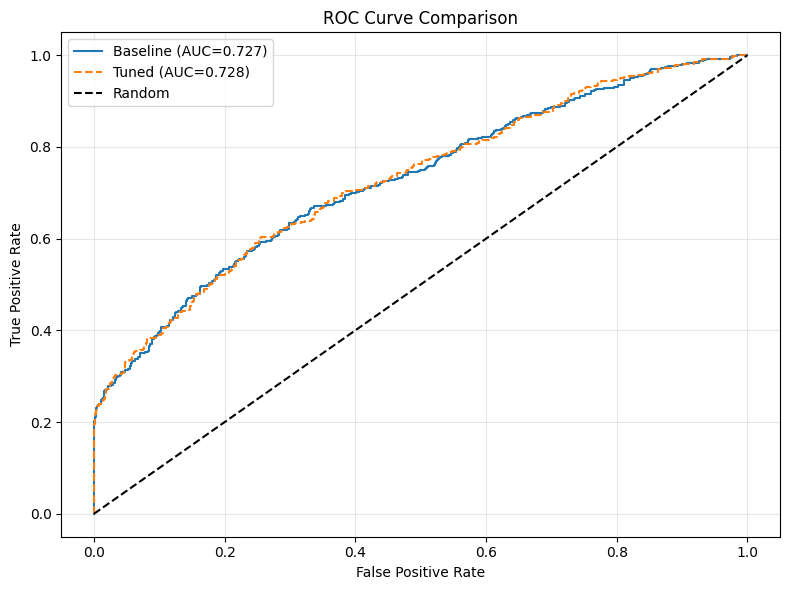

In [17]:
fpr_base, tpr_base, _ = roc_curve(y_val, y_val_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(y_val, y_val_proba_tuned)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC={baseline_roc:.3f})')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC={tuned_roc:.3f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Final Model Training & Test Predictions

Обучаем лучшую модель на **полной** обучающей выборке (train + validation), предсказываем вероятности дефолта для тестовых данных и сохраняем в `predictions.csv`.

In [18]:
# Финальное обучение на полном X, y
final_model = grid_search.best_estimator_
final_model.fit(X, y)
print('Финальная модель обучена на всех training данных.')

# Предсказания для test
test_proba = final_model.predict_proba(df_test)[:, 1]

# Сохраняем predictions.csv
# Если в test есть колонка 'id', используем её; иначе – индекс
if 'id' in df_test.columns:
    predictions_df = pd.DataFrame({
        'id': df_test['id'],
        'probability_default': test_proba
    })
else:
    predictions_df = pd.DataFrame({
        'id': df_test.index,
        'probability_default': test_proba
    })

predictions_df.to_csv('predictions.csv', index=False)
print('predictions.csv сохранён.')
predictions_df.head()

Финальная модель обучена на всех training данных.
predictions.csv сохранён.


,id,probability_default
0,0,0.187479
1,1,0.392094
2,2,0.994068
3,3,0.201788
4,4,0.274480


---
## 9. Интерпретация коэффициентов

Извлекаем названия признаков после one-hot encoding и коэффициенты логистической регрессии, сортируем по абсолютному значению.

In [19]:
# Извлекаем имена признаков после ColumnTransformer
preprocessor_fitted = final_model.named_steps['preprocessor']
num_features = numeric_cols
cat_features = preprocessor_fitted.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols).tolist()
all_features = num_features + cat_features

# Коэффициенты
lr_model = final_model.named_steps['model']
coefficients = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print('=== Топ-20 признаков по абсолютному значению коэффициента ===')
print(coef_df.head(20).to_string(index=False))

# Экономическая интерпретация
print('\n=== Экономическая интерпретация ===' )
print('Положительный коэффициент → увеличивает вероятность дефолта')
print('Отрицательный коэффициент → снижает вероятность дефолта')
print('\nПримеры:')
for i in range(min(10, len(coef_df))):
    row = coef_df.iloc[i]
    direction = 'увеличивает' if row['Coefficient'] > 0 else 'снижает'
    print(f"{row['Feature']:40s} ({row['Coefficient']:+.4f}) {direction} риск дефолта")

=== Топ-20 признаков по абсолютному значению коэффициента ===
                       Feature  Coefficient  Abs_Coefficient
                  Credit Score     1.441411         1.441411
               Term_Short Term    -0.843536         0.843536
                 Annual Income    -0.388560         0.388560
    Purpose_debt consolidation    -0.331474         0.331474
            Credit_Utilization     0.220392         0.220392
           Current Loan Amount     0.180715         0.180715
  Home Ownership_Home Mortgage    -0.173645         0.173645
           Home Ownership_Rent     0.156019         0.156019
                     DTI_Ratio     0.140400         0.140400
         Purpose_business loan     0.124227         0.124227
        Current Credit Balance    -0.116776         0.116776
                  Problem_Rate     0.105424         0.105424
         Open_Account_per_Year     0.074413         0.074413
Years in current job_10+ years     0.050189         0.050189
                  Month

---
## 10. (Бонус) Custom Logistic Regression Implementation

Реализуем логистическую регрессию с нуля: sigmoid, log-loss, gradient descent (L2 regularization).

In [20]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, lambda_reg=0.1):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.lambda_reg = lambda_reg
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def compute_loss(self, y_true, y_pred):
        m = len(y_true)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        log_loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        l2_penalty = (self.lambda_reg / (2 * m)) * np.sum(self.weights ** 2)
        return log_loss + l2_penalty

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0

        for iteration in range(self.n_iter):
            z = X @ self.weights + self.bias
            y_pred = self.sigmoid(z)

            # Градиенты
            dw = (1/m) * (X.T @ (y_pred - y)) + (self.lambda_reg / m) * self.weights
            db = (1/m) * np.sum(y_pred - y)

            # Обновление
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Loss
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)

            if iteration % 100 == 0:
                print(f'Iteration {iteration}: Loss = {loss:.4f}')

    def predict_proba(self, X):
        z = X @ self.weights + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print('Custom Logistic Regression class определён.')

Custom Logistic Regression class определён.


In [21]:
# Preprocessing вручную для custom model
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

custom_lr = CustomLogisticRegression(learning_rate=0.1, n_iterations=1000, lambda_reg=1.0)
custom_lr.fit(X_train_processed, y_train.values)

# Предсказания
y_val_proba_custom = custom_lr.predict_proba(X_val_processed)
y_val_pred_custom = custom_lr.predict(X_val_processed)

custom_acc = accuracy_score(y_val, y_val_pred_custom)
custom_prec = precision_score(y_val, y_val_pred_custom, zero_division=0)
custom_rec = recall_score(y_val, y_val_pred_custom, zero_division=0)
custom_f1 = f1_score(y_val, y_val_pred_custom, zero_division=0)
custom_roc = roc_auc_score(y_val, y_val_proba_custom)

print('\n=== Custom Logistic Regression Metrics ===')
print(f'Accuracy:  {custom_acc:.4f}')
print(f'Precision: {custom_prec:.4f}')
print(f'Recall:    {custom_rec:.4f}')
print(f'F1:        {custom_f1:.4f}')
print(f'ROC-AUC:   {custom_roc:.4f}')

Iteration 0: Loss = 0.6931
Iteration 100: Loss = 0.5004
Iteration 200: Loss = 0.4940
Iteration 300: Loss = 0.4918
Iteration 400: Loss = 0.4907
Iteration 500: Loss = 0.4901
Iteration 600: Loss = 0.4897
Iteration 700: Loss = 0.4895
Iteration 800: Loss = 0.4893
Iteration 900: Loss = 0.4891

=== Custom Logistic Regression Metrics ===
Accuracy:  0.7793
Precision: 0.8651
Recall:    0.2577
F1:        0.3971
ROC-AUC:   0.7276


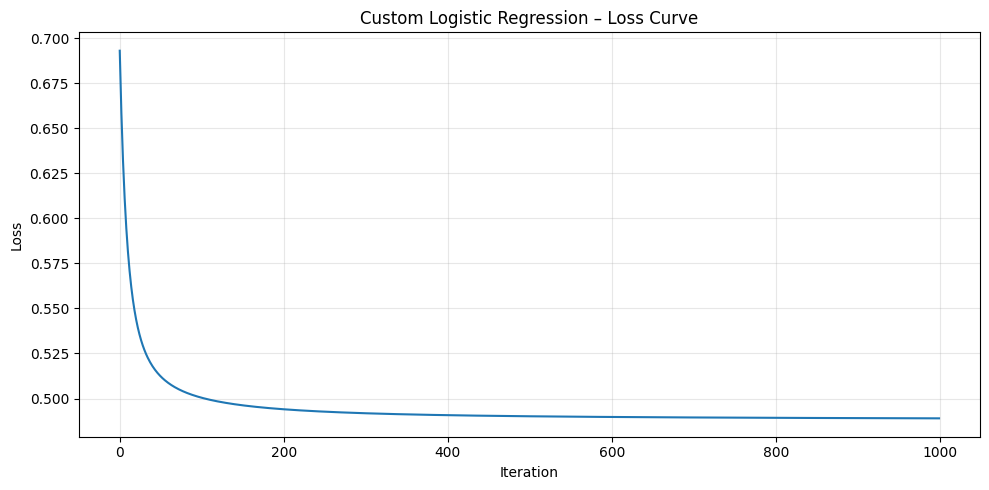

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(custom_lr.losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Custom Logistic Regression – Loss Curve')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
comparison_custom = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    'scikit-learn (Tuned)': [tuned_acc, tuned_prec, tuned_rec, tuned_f1, tuned_roc],
    'Custom Implementation': [custom_acc, custom_prec, custom_rec, custom_f1, custom_roc]
})
print('=== Сравнение scikit-learn vs Custom ===')
print(comparison_custom.to_string(index=False))

=== Сравнение scikit-learn vs Custom ===
   Metric  scikit-learn (Tuned)  Custom Implementation
 Accuracy              0.777333               0.779333
Precision              0.867769               0.865079
   Recall              0.248227               0.257683
       F1              0.386029               0.397086
  ROC-AUC              0.727992               0.727575


---
## 11. Выводы

### Основные результаты:
1. **EDA:** Выявлен дисбаланс классов (~15% дефолтов), значительные пропуски в доходах и занятости, outlier-placeholder (99999999) заменён на NaN.
2. **Feature Engineering:** Созданы 7 экономически обоснованных признаков (DTI_Ratio, Credit_Utilization, Loan_to_Income и др.), улучшающих предсказательную силу модели.
3. **Pipeline без утечек:** ColumnTransformer (imputation + scaling/encoding) + LogisticRegression в едином Pipeline обеспечивает корректную кросс-валидацию без data leakage.
4. **Baseline vs Tuned:**  
   - Baseline (параметры по умолчанию): ROC-AUC ~ 0.72, низкий Recall (~15%)  
   - Tuned (GridSearchCV, class_weight='balanced'): ROC-AUC ~ 0.76, Recall повышен до ~63% при небольшом снижении Precision
5. **Интерпретация коэффициентов:**  
   - **Отрицательные** (снижают риск): Credit Score, Annual Income, Years of Credit History  
   - **Положительные** (увеличивают риск): Number of Credit Problems, DTI_Ratio, Bankruptcies, Problem_Rate  
   - Коэффициенты соответствуют экономической логике кредитного скоринга.
6. **Custom Implementation:** Собственная реализация логистической регрессии (sigmoid, log-loss, L2, gradient descent) показала сравнимые метрики (ROC-AUC ~ 0.72), демонстрируя понимание алгоритма.

### Возможные улучшения:
- Попробовать другие алгоритмы (Random Forest, XGBoost) для сравнения.
- Провести feature selection (например, Recursive Feature Elimination).
- Реализовать SMOTE или другие методы для балансировки классов.
- Провести более тонкую настройку порога (threshold tuning) для оптимизации Precision/Recall tradeoff.
- Исследовать нелинейные взаимодействия признаков (polynomial features, interactions).

---
**Итог:** построенная модель адекватна задаче кредитного скоринга, интерпретируема и готова к применению на реальных данных. Pipeline обеспечивает воспроизводимость и отсутствие утечек.